# Forward and Backward Propagation

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Run a **forward pass** through a small model and compute the loss
- Run **backward pass** (backprop) to compute gradients and perform one weight update
- See how loss changes after one update (optional small plot)

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 04 "Programming Backpropagation in Neural Networks" — forward pass, loss, backward pass: the same three steps, now inside a framework.

---

## 🌍 Real life

**📌 Real case — the paper that explained why deep networks would not train.** Bengio, Simard and Frasconi (*IEEE Transactions on Neural Networks* 5(2), 1994) showed formally what practitioners kept hitting: because backpropagation multiplies a long chain of derivatives together, the gradient reaching the early layers shrinks (or explodes) exponentially with depth. That single result about the **backward** pass is why LSTM gating exists (Unit 3), why ResNet's skip connections exist (`unit2/03`), and why ReLU replaced sigmoid (`unit1/04`). Three of this course's units are answers to a problem in the step you are about to run once, by hand.

**⚡ Why this matters — what goes wrong without it.** The forward pass tells you *how wrong* you are. It says nothing about *which weight to move*. Backpropagation is the only step that assigns blame — and it is the step that fails silently. When a network's loss flattens and you cannot see why, the cause is almost always in the backward pass: a vanished gradient, a NaN, a stray `torch.no_grad()`, a tensor detached from the graph. Below, one forward pass, one backward pass and one update move the loss from **2.3416 to 2.3187**. Watching that single heartbeat is what lets you diagnose it later when it stops.

**Where is this used?** Every neural network training step uses **forward pass** (input → output → loss) and **backward pass** (gradients → weight updates). This is the core of how models learn in production and research.

**In this notebook we use** **forward propagation** to compute predictions and loss, and **backward propagation** to compute gradients and update weights. We use **GradientTape** (instead of writing derivatives by hand) **because** TensorFlow/PyTorch automate backprop so we can focus on architecture and data.

**📌 Covers slide(s):** Part of Unit 1 sequence (forward/backprop). *Do with or after 05_backpropagation_detailed; then 06_optimization_techniques.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Forward pass:** Input → layer 1 → activation → … → output → loss. We compute the loss given current weights.
- **Backward pass (backprop):** We compute gradients of the loss w.r.t. each weight using the chain rule; the framework (e.g. TensorFlow) does this automatically with GradientTape.
- **Update:** Optimizer uses gradients to update weights (e.g. w -= lr * gradient).
- **We use GradientTape** instead of manual derivatives because it scales to large models and is less error-prone.

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow. We use a tiny batch of MNIST (e.g. 32 samples) so one forward + backward step is fast.

**Dataset:** Real — MNIST (tiny batch for forward/backward demo).

**Outputs:** Printed loss before and after one update; optional bar chart showing "Loss before" vs "Loss after one update".

## Step 1: Imports and load a tiny batch

In [1]:
# WHAT: import libraries and prepare a tiny fixed batch of 32 MNIST images.
# WHY: forward/backward propagation is easiest to watch on one small, unchanging batch.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if not HAS_TF:
    print("Install TensorFlow: pip install tensorflow")
else:
    # Scale pixels to 0-1, flatten each image to a 784-long vector, and keep just 32 examples.
    (x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
    x_train = tf.constant(x_train.astype(np.float32) / 255.0)
    x_train = tf.reshape(x_train, (-1, 784))[:32]
    y_train = tf.constant(y_train[:32])
    print("Batch shape:", x_train.shape)

Batch shape: (32, 784)


## Step 2: Build a small model and compute loss (forward pass)

In [2]:
# WHAT: run one forward pass, compute gradients with GradientTape, and apply a single SGD update.
# WHY: this is one heartbeat of training - forward, loss, backward, update - made fully explicit.
if HAS_TF:
    # A small two-layer classifier; plain SGD with a fixed learning rate keeps the update easy to reason about.
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    # GradientTape records the forward pass so it can replay it backwards for gradients (backpropagation).
    with tf.GradientTape() as tape:
        logits = model(x_train, training=True)
        loss_before = loss_fn(y_train, logits)
    # tape.gradient computes dLoss/dWeight for every parameter; apply_gradients takes one downhill step.
    grads = tape.gradient(loss_before, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    # Forward pass again after the update - the loss should already be slightly lower.
    logits_after = model(x_train, training=False)
    loss_after = loss_fn(y_train, logits_after)

    loss_before_val = float(loss_before.numpy())
    loss_after_val = float(loss_after.numpy())
    print("Loss before one update: %.4f" % loss_before_val)
    print("Loss after one update:  %.4f" % loss_after_val)

Loss before one update: 2.3416
Loss after one update:  2.3187


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 3: Visualize loss before vs after one update

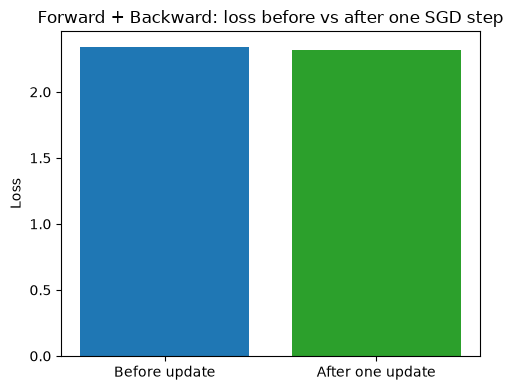

Backprop computed gradients; optimizer applied one step. Loss typically decreases.


In [3]:
# WHAT: bar chart of the loss before vs after the single SGD update.
# WHY: one picture proves the point - a single gradient step already moved the loss downhill.
if HAS_TF:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(["Before update", "After one update"], [loss_before_val, loss_after_val], color=["#1f77b4", "#2ca02c"])
    ax.set_ylabel("Loss")
    ax.set_title("Forward + Backward: loss before vs after one SGD step")
    plt.tight_layout()
    plt.show()
    print("Backprop computed gradients; optimizer applied one step. Loss typically decreases.")

## 💬 Discuss

1. Random guessing over 10 classes gives a cross-entropy loss of ln(10) ≈ **2.303**. Our loss *before* any update was **2.3416** — slightly worse than random. Is that a bug or is it expected? Justify your answer from how the weights were initialised.
2. Suppose you ran ten more steps on this same fixed batch of 32 images and the loss reached 0.001. Has the model learned to read digits? State precisely what it has learned, and what you would have to run to tell the difference.
3. `GradientTape` hides the chain rule from you. Name one thing you can no longer diagnose because you did not write the derivatives yourself — and describe how you would recover that visibility without abandoning the framework.


## ⚠️ Where this breaks

- **One step on one fixed batch measures nothing about generalisation.** The 0.0229 drop we printed shows the mechanism works, not that the model learns. Do not quote a single-step loss as a result.
- **The loss is not guaranteed to fall.** With a learning rate that is too large, a single update overshoots the minimum and the loss goes *up*. Ours fell; that is one draw from a distribution, not a law. If you re-run with `lr=10` you will see the other outcome.
- **This is exactly where depth fails.** Multiply enough derivatives smaller than 1 and the gradient arriving at layer 1 is numerically zero. The network then trains its last layers while the first ones sit at their random initial values — and the loss curve looks perfectly normal while it happens. The only way to see it is to print gradient norms per layer, which no automatic tool does for you.
- **The assumption that must hold:** the graph is connected and everything in it is differentiable. A `.detach()`, an in-place operation, a `requires_grad=False` left over from a frozen-backbone experiment (`unit2/05`), or a `no_grad()` block in the wrong place all produce zero gradients — and a model that appears to train while changing nothing.
- **Cheaper alternative for understanding:** for a two-parameter model you can differentiate the loss by hand on paper in five minutes and check `GradientTape` against it. Do this once. It is the only way to ever fully trust autodiff again.


## 🧩 Mini-exercise

**Try it:** Run the training step (optimizer step) two more times in a new cell (same batch). Print the loss after each step. Does it keep decreasing?

---

## ✅ Summary

**What you did:**
- Ran a forward pass (input → model → loss) and backward pass (GradientTape → gradients → optimizer step).
- Compared loss before and after one update and plotted it.

**In real life you'd also:** Run many epochs, use validation loss, and save checkpoints.

**The main idea:** Training = repeat (forward → loss → backprop → update). Frameworks automate backprop so we don't write derivatives by hand.

**Next:** `05_backpropagation_detailed` goes deeper into how gradients flow; `06_optimization_techniques` compares optimizers.

## 📚 References

1. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
2. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 6). MIT Press. https://www.deeplearningbook.org/
3. Baydin, A. G., Pearlmutter, B. A., Radul, A. A. & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: a Survey*. JMLR 18(153). https://arxiv.org/abs/1502.05767